In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
!pip install torch-snippets==0.495
from torch_snippets import *

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 386.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 778.6 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 2.3 MB/s eta 0:00:00
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26325 sha256=2a5fe401372a2bf5dc3f22f45ea02239ba40703fd9876f73543a09cd036420c8
  Stored in directory: /root/.cache/pip/wheels/35/f3/15/01aa6571f0a72ee6ae7b827c1491c37a1f72d686fd22b43b0e
Successfully built typing


The dataset consists of $151$ aerial images of the Boston area. It covers mostly urban and suburban areas and buildings of all sizes. Each of the images has $1500 \times 1500$ pixels for an area of $2.25$ square kilometers. In total the dataset covers $340$ square kilometers area.

An accompanying **metadata.csv** is provided with each image ID, the split it belongs to, image urls and path to it.

In [3]:
IMG_ROOT = '/input/massachusetts-buildings-dataset/'
df = pd.read_csv('/input/massachusetts-buildings-dataset/metadata.csv')

train_df = df.loc[df['split'] == 'train']
tst_df = df.loc[df['split'] == 'test']
print("Training dataset size:", len(train_df))
print("Test dataset size:", len(tst_df))

Training dataset size: 137
Test dataset size: 10


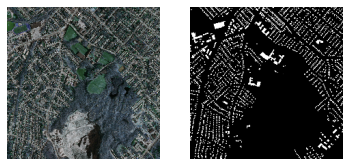

In [4]:
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

tfms = transforms.Compose([
#     transforms.RandomHorizontalFlip(0.3),
#     transforms.RandomRotation(40),
#     transforms.RandomVerticalFlip(0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], # imagenet
                         [0.229, 0.224, 0.225])
])

class BuildingDataset(Dataset):
    def __init__(self, df, root=IMG_ROOT):
        self.df = df
        self.root = root
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        w, h = 224, 224
        img_path = self.root+self.df.iloc[idx]['png_image_path']
        mask_path = self.root+self.df.iloc[idx]['png_label_path']
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path)
        img = cv2.resize(img, (224, 224))
        mask = cv2.resize(mask, (224, 224))
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
        return img, mask
    
    def collate_fn(self, batch):
        images, masks = list(zip(*batch))
        images = torch.cat([tfms(img.copy()/255.)[None] for img in images]).float().to(device)
        masks = torch.cat([torch.Tensor(mask[None]) for mask in masks]).long().to(device)
        return images, masks
    
tr_ds = BuildingDataset(train_df)
tst_ds = BuildingDataset(tst_df)

tr_dl = DataLoader(tr_ds, batch_size=4, drop_last=True, shuffle=True,
                  collate_fn=tr_ds.collate_fn)
tst_dl = DataLoader(tr_ds, batch_size=1, drop_last=True, shuffle=True,
                  collate_fn=tst_ds.collate_fn)

img, mask = tr_ds[10]
fig, ax = plt.subplots(1, 2)
show(img, ax=ax[0])
show(mask, ax=ax[1])

<a id="1"></a>
# <p style="padding:10px;background-color:#a7fabd;margin:0;color:black;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 100px 50px;overflow:hidden;font-weight:500">Model</p>

In [5]:
import torch.nn as nn
from torchvision.models import vgg16_bn

def conv(in_channels, out_channels):
    return nn.Sequential(
      nn.Conv2d(in_channels, out_channels, kernel_size=3,
                stride=1, padding=1),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True)
  )

def up_conv(in_channels, out_channels):
    return nn.Sequential(
     nn.ConvTranspose2d(in_channels, out_channels, 
                         kernel_size=2, stride=2),
     nn.ReLU(inplace=True)
  )

class UNet(nn.Module):
    def __init__(self, pretrained=True, out_channels=12):
        super().__init__()
        self.backbone = vgg16_bn(pretrained=True).to(device).features
        self.down1 = nn.Sequential(*self.backbone[:6]) # 64
        self.down2 = nn.Sequential(*self.backbone[6:13]) # 128
        self.down3 = nn.Sequential(*self.backbone[13:20]) # 256
        self.down4 = nn.Sequential(*self.backbone[20:27]) # 512
        self.down5 = nn.Sequential(*self.backbone[27:34]) # 512

        self.bottleneck = nn.Sequential(*self.backbone[34:]) # 512
        self.conv_bottleneck = conv(512, 1024)

        self.up_conv5 = up_conv(1024, 512)
        self.merge_conv5 = conv(512+512, 512)
        self.up_conv4 = up_conv(512, 256)
        self.merge_conv4 = conv(512 + 256, 256)
        self.up_conv3 = up_conv(256, 128)
        self.merge_conv3 = conv(256+128, 128)
        self.up_conv2 = up_conv(128, 64)
        self.merge_conv2 = conv(128+64, 64)
        self.up_conv1 = up_conv(64, 32)
        self.merge_conv1 = conv(32+64, 32)

        self.final_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # encoder
        x_1 = self.down1(x)
        x_2 = self.down2(x_1)
        x_3 = self.down3(x_2)
        x_4 = self.down4(x_3)
        x_5 = self.down5(x_4)
        # bottleneck
        x = self.bottleneck(x_5)
        x = self.conv_bottleneck(x)
        # decoder
        x = self.up_conv5(x)
        x = self.merge_conv5(torch.cat([x, x_5], dim=1))
        x = self.up_conv4(x)
        x = self.merge_conv4(torch.cat([x, x_4], dim=1))
        x = self.up_conv3(x)
        x = self.merge_conv3(torch.cat([x, x_3], dim=1))
        x = self.up_conv2(x)
        x = self.merge_conv2(torch.cat([x, x_2], dim=1))
        x = self.up_conv1(x)
        x = self.merge_conv1(torch.cat([x, x_1], dim=1))

        x = self.final_conv(x)
        return x

model = UNet().to(device)
model(torch.zeros((1, 3, 224, 224)).to(device))

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


  0%|          | 0.00/528M [00:00<?, ?B/s]

tensor([[[[-0.3926, -2.4529, -0.5703,  ..., -1.0512, -1.5726, -2.2755],
          [-3.2240, -3.3825, -1.9989,  ..., -2.1209, -2.9966, -3.0140],
          [-0.8536, -4.7010, -0.8005,  ..., -1.4552, -1.6948, -2.1408],
          ...,
          [-1.6549, -3.4156, -0.5880,  ..., -1.2767, -1.8030, -3.2775],
          [-1.2390, -3.1418, -0.4083,  ..., -1.3878, -2.9231, -4.0419],
          [-2.0860, -2.9209, -1.3508,  ..., -2.1075, -2.8941, -5.2825]],

         [[-1.0293,  0.8786,  1.1708,  ...,  0.6153, -0.6985,  2.3501],
          [-0.6051, -4.1441, -2.9608,  ..., -2.6113, -4.3814, -3.0311],
          [-0.9404, -2.4478,  0.1204,  ..., -1.2253, -1.7230, -0.0714],
          ...,
          [-1.1704, -1.9986, -0.2153,  ..., -0.2163, -1.3208, -0.2265],
          [-0.2571, -1.5111, -0.1234,  ..., -1.6933, -1.2430, -1.4624],
          [-2.1285,  0.3880,  1.6500,  ...,  1.9368,  1.1316,  1.7972]],

         [[-0.6003, -3.2860, -1.7246,  ..., -2.4029, -0.7737, -0.9201],
          [ 3.1859,  2.0521,  

<a id="1"></a>
# <p style="padding:10px;background-color:#a7fabd;margin:0;color:black;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 100px 50px;overflow:hidden;font-weight:500">Training</p>

In [6]:
def loss_fn(preds, targets):
    loss_fn = nn.CrossEntropyLoss()
    loss = loss_fn(preds, targets)
    acc = (torch.max(preds, 1)[1] == targets).float().mean()
    return loss, acc

def train_batch(model, batch, optim, loss_fn):
    model.train()
    imgs, masks = batch
    pred_masks = model(imgs)
    optim.zero_grad()
    loss, acc = loss_fn(pred_masks, masks)
    loss.backward()
    optim.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, batch, loss_fn):
    model.eval()
    imgs, masks = batch
    pred_masks = model(imgs)
    loss, acc = loss_fn(pred_masks, masks)
    return loss.item(), acc.item()

model = UNet(out_channels=300).to(device)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = loss_fn
n_epochs = 50
log = Report(n_epochs)
for e in range(n_epochs):
    N = len(tr_dl)
    for i, batch in enumerate(tr_dl):
        loss, acc = train_batch(model, batch, optim, loss_fn)
        log.record(e+(i+1)/N, trn_loss=loss, trn_acc=acc, end='\r')
    N = len(tst_dl)
    for i, batch in enumerate(tst_dl):
        loss, acc = validate_batch(model, batch, loss_fn)
        log.record(e+(i+1)/N, val_loss=loss, val_acc=acc, end='\r')
  
    log.report_avgs(e+1)

EPOCH: 1.000	trn_loss: 4.918	trn_acc: 0.420	val_loss: 4.447	val_acc: 0.517	(38.49s - 1886.14s remaining)
EPOCH: 2.000	trn_loss: 3.784	trn_acc: 0.545	val_loss: 3.192	val_acc: 0.524	(68.15s - 1635.51s remaining)
EPOCH: 3.000	trn_loss: 2.712	trn_acc: 0.547	val_loss: 1.972	val_acc: 0.596	(97.92s - 1534.13s remaining)
EPOCH: 4.000	trn_loss: 1.723	trn_acc: 0.694	val_loss: 1.364	val_acc: 0.790	(127.56s - 1466.93s remaining)
EPOCH: 5.000	trn_loss: 1.046	trn_acc: 0.866	val_loss: 0.943	val_acc: 0.874	(156.99s - 1412.91s remaining)
EPOCH: 6.000	trn_loss: 0.783	trn_acc: 0.870	val_loss: 0.737	val_acc: 0.873	(186.60s - 1368.38s remaining)
EPOCH: 7.000	trn_loss: 0.696	trn_acc: 0.871	val_loss: 0.669	val_acc: 0.872	(216.27s - 1328.51s remaining)
EPOCH: 8.000	trn_loss: 0.654	trn_acc: 0.873	val_loss: 0.650	val_acc: 0.876	(245.83s - 1290.60s remaining)
EPOCH: 9.000	trn_loss: 0.628	trn_acc: 0.874	val_loss: 0.635	val_acc: 0.869	(275.50s - 1255.06s remaining)
EPOCH: 10.000	trn_loss: 0.618	trn_acc: 0.875	val_

100%|██████████| 151/151 [00:00<00:00, 582.71it/s]


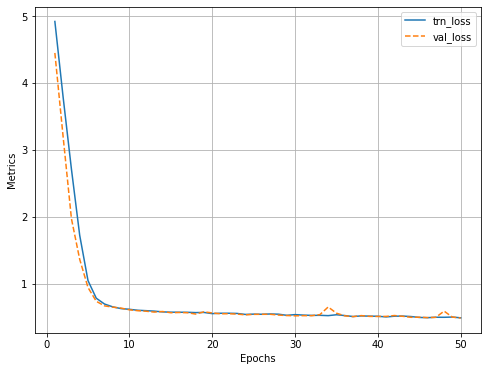

In [7]:
log.plot_epochs(['trn_loss', 'val_loss'])

<a id="1"></a>
# <p style="padding:10px;background-color:#a7fabd;margin:0;color:black;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 100px 50px;overflow:hidden;font-weight:500">Testing</p>

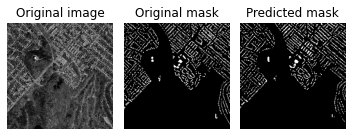

In [8]:
im, mask = next(iter(tst_dl))
_mask = model(im)
_, _mask = torch.max(_mask, dim=1)
subplots([im[0].permute(1,2,0).detach().cpu()[:,:,0], mask.permute(1,2,0).detach().cpu()[:,:,0]
,_mask.permute(1,2,0).detach().cpu()[:,:,0]],
nc=3, titles=['Original image','Original mask','Predicted mask'])